In [1]:
# =====================================================
# EDA ANÁLISIS DEL MEDIOCENTRO SUSTITUTO DE TONI KROOS
# =====================================================

# =====================================================
# PASO 1: IMPORTAR LIBRERÍAS Y CONFIGURAR GRÁFICOS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
from adjustText import adjust_text

# Se configura el estilo de los gráficos para que sean
# más claros y profesionales.

sns.set_style("whitegrid")
sns.set_context("talk")

In [2]:
# =====================================================
# PASO 2: CARGAR DATASET
# =====================================================

# Se carga el dataset con estadísticas de jugadores de
# las cinco grandes ligas europeas.

# El separador es ";" porque el archivo proviene de
# FBref o de exportaciones similares.

df = pd.read_csv("top5-players24-25.csv", sep=";")

# Eliminamos posibles espacios en la columna de posición
# para evitar errores al filtrar posiciones.

df["Pos"] = df["Pos"].str.strip()

In [3]:
# =====================================================
# PASO 3: AGRUPAR POSICIONES
# =====================================================

# El dataset contiene posiciones combinadas como:
# DF,MF   MF,FW   DF,FW etc.
#
# Para facilitar el análisis exploratorio se agrupan
# todas las posiciones en cuatro grandes grupos:
#
# Goalkeeper
# Defender
# Midfielder
# Forward

def group_position(pos):

    if "GK" in pos:
        return "Goalkeeper"

    elif "DF" in pos:
        return "Defender"

    elif "MF" in pos:
        return "Midfielder"

    elif "FW" in pos:
        return "Forward"

    else:
        return "Other"

df["Position_group"] = df["Pos"].apply(group_position)

# Comprobamos cuántos jugadores hay en cada grupo

print(df["Position_group"].value_counts())

Position_group
Midfielder    1144
Defender      1126
Forward        371
Goalkeeper     212
Name: count, dtype: int64


In [4]:
# =====================================================
# PASO 4: VARIABLES DEL MODELO
# =====================================================

# Estas variables representan métricas relacionadas
# con creación de juego y progresión del balón.
#
# Son las variables utilizadas posteriormente en el
# modelo de similitud para encontrar jugadores
# comparables a Toni Kroos.

features = [
    "Ast",
    "xAG",
    "PrgP",
    "PrgC",
    "Ast_90",
    "xAG_90"
]

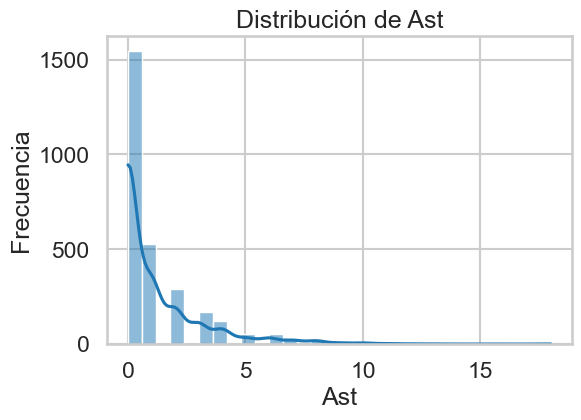

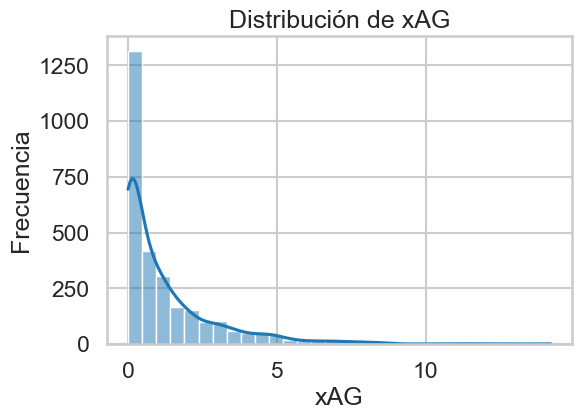

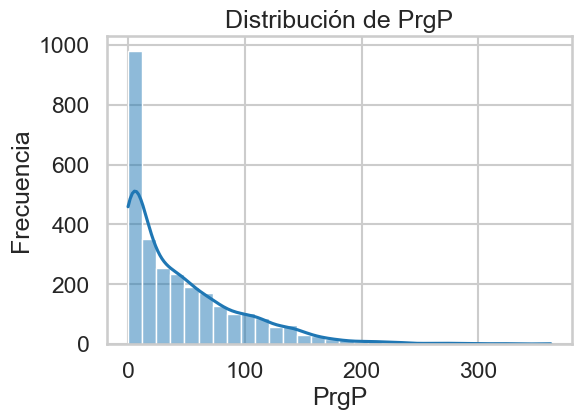

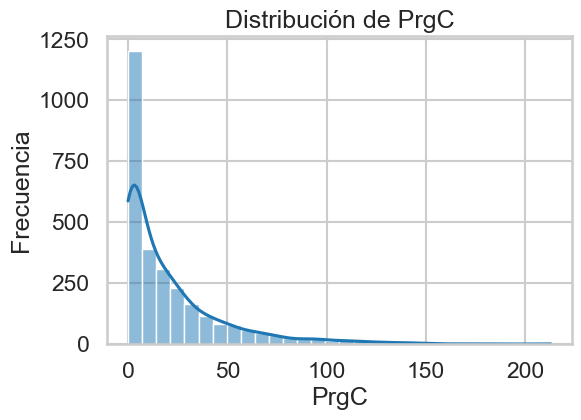

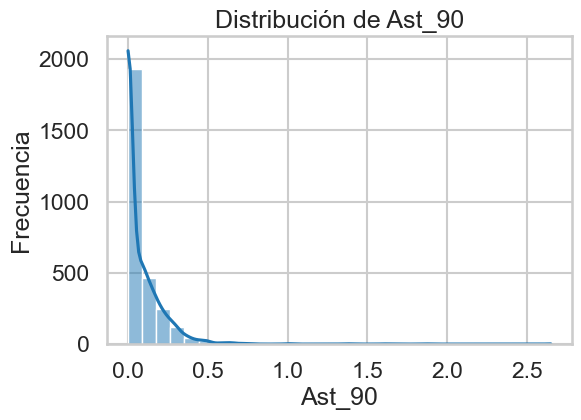

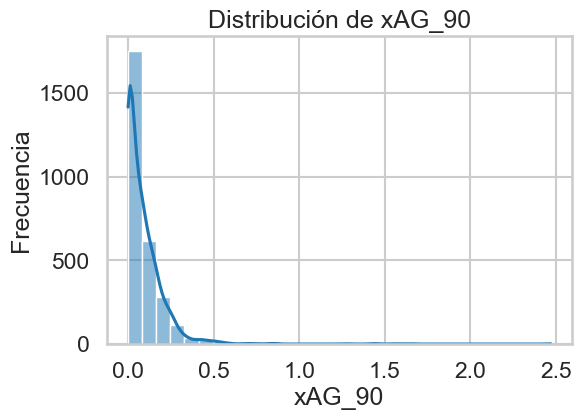

In [5]:
# =====================================================
# PASO 5: HISTOGRAMAS
# =====================================================

# Los histogramas permiten analizar la distribución
# de cada variable y detectar posibles sesgos.
#
# En datasets de fútbol es habitual encontrar
# distribuciones con sesgo positivo, ya que la mayoría
# de jugadores tienen valores bajos y pocos jugadores
# presentan valores muy altos.

for col in features:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    plt.show()

In [6]:
# =====================================================
# PASO 6: ESTANDARIZACIÓN DE VARIABLES
# =====================================================

# Se utiliza StandardScaler para estandarizar las
# variables.
#
# Esto transforma cada variable para que tenga:
#
# media = 0
# desviación estándar = 1
#
# La estandarización permite comparar variables que
# originalmente tienen escalas diferentes.

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[features] = scaler.fit_transform(df_scaled[features])

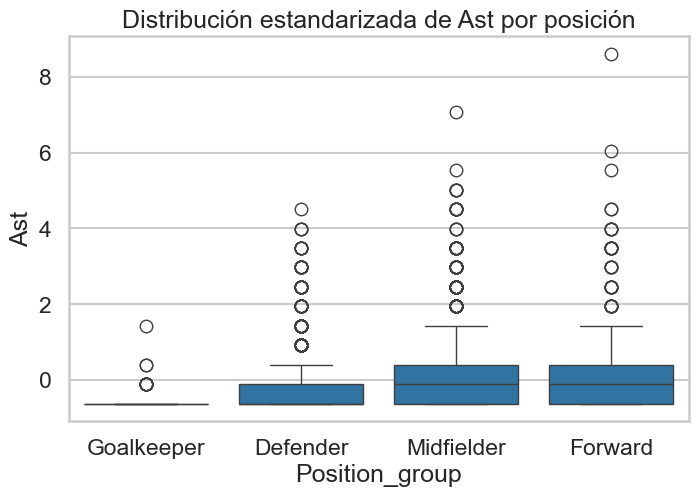

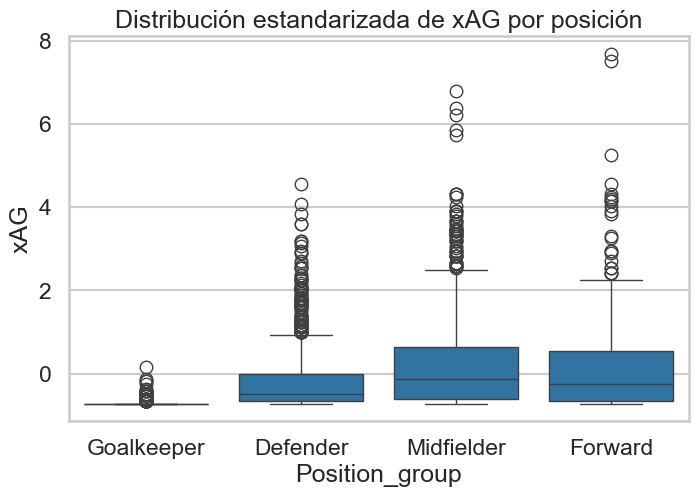

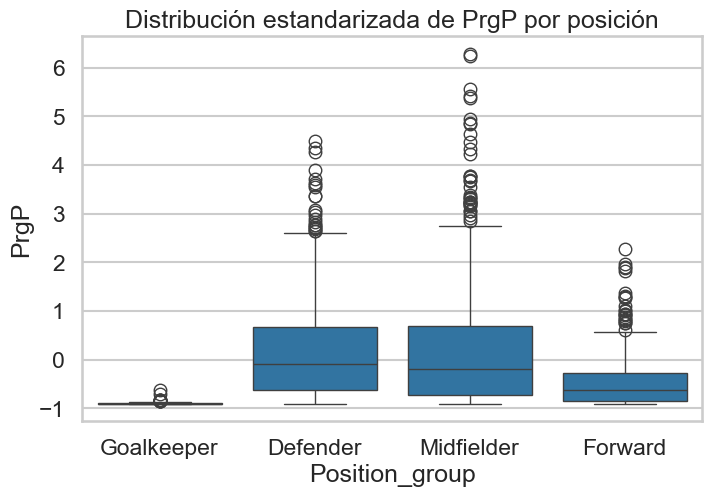

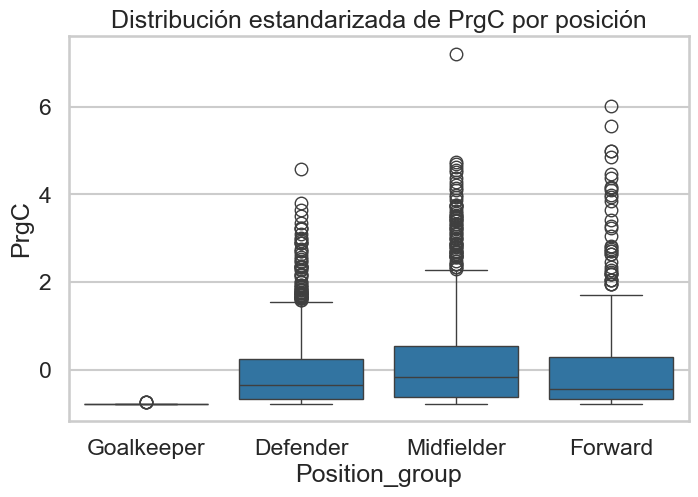

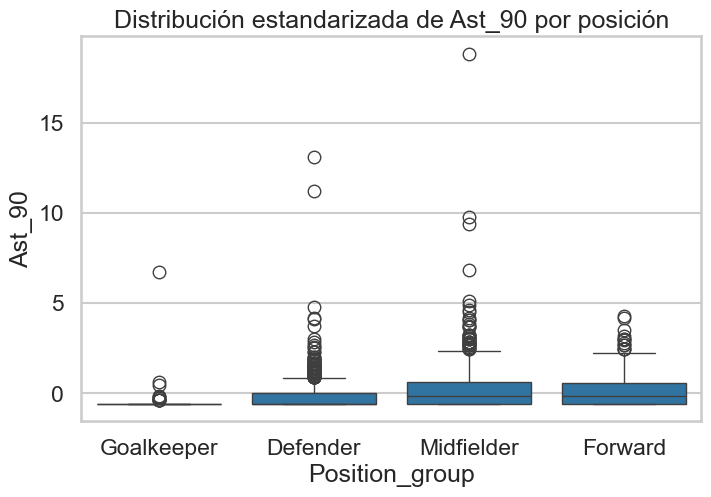

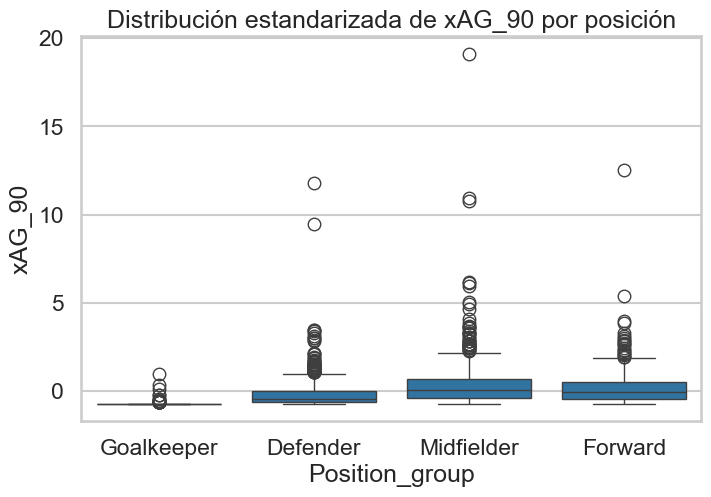

In [7]:
# =====================================================
# PASO 7: BOXPLOTS POR VARIABLE
# =====================================================

# Los boxplots permiten comparar la distribución de
# cada variable entre diferentes posiciones.

position_order = [
    "Goalkeeper",
    "Defender",
    "Midfielder",
    "Forward"
]

for col in features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df_scaled,
        x="Position_group",
        y=col,
        order=position_order
    )

    plt.title(f"Distribución estandarizada de {col} por posición")

    plt.show()

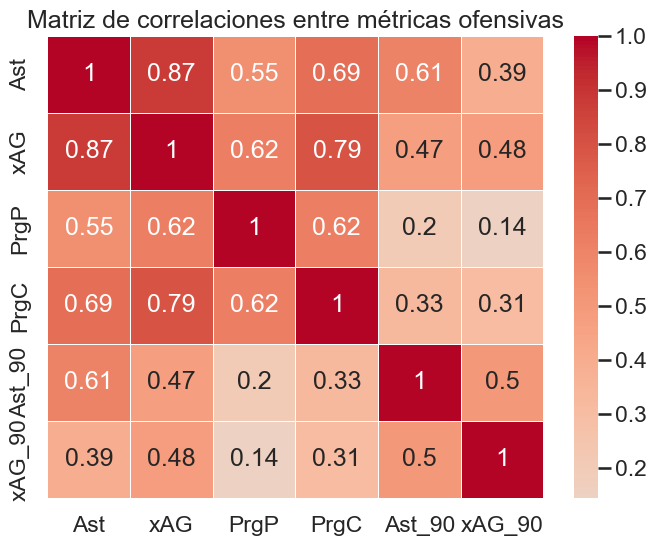

In [8]:
# =====================================================
# PASO 8: MATRIZ DE CORRELACIONES
# =====================================================

# La matriz de correlaciones permite analizar las
# relaciones entre las variables seleccionadas.
#
# El objetivo es comprobar si las variables están
# relacionadas entre sí pero sin ser completamente
# redundantes.

corr = df[features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlaciones entre métricas ofensivas")

plt.show()

In [9]:
# =====================================================
# PASO 9: FILTRAR MEDIOCAMPISTAS
# =====================================================

# Para analizar las variables filtro del modelo de
# scouting se consideran únicamente mediocampistas.
#
# Se seleccionan todos los jugadores cuya posición
# contenga MF (incluyendo MF,FW o DF,MF).

df_mf = df[df["Pos"].str.contains("MF", na=False)]

In [10]:
# =====================================================
# PASO 10: VARIABLES FILTRO
# =====================================================

# Estas variables se utilizan posteriormente para
# aplicar filtros en el proceso de scouting.

filter_vars = [
    "Age",
    "Min",
    "90s"
]

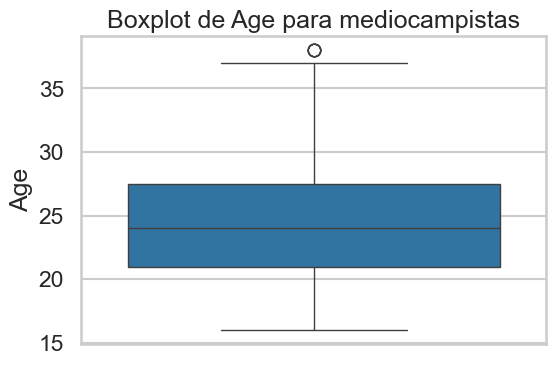

Mediana de Age:  24.0


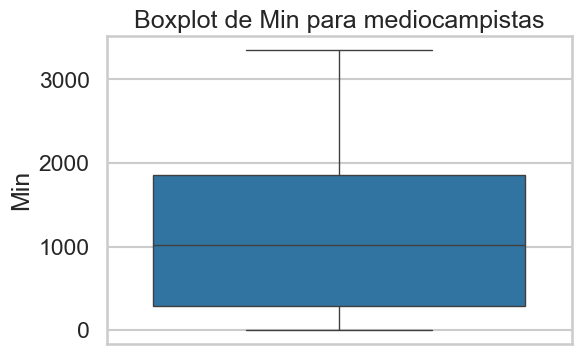

Mediana de Min:  1013.0


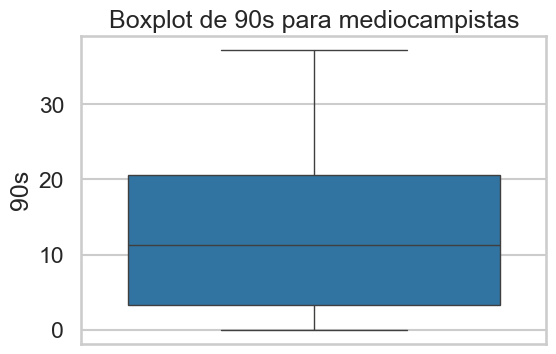

Mediana de 90s:  11.3


In [11]:
# =====================================================
# PASO 11: BOXPLOTS VARIABLES FILTRO
# =====================================================

# Se generan boxplots para observar la distribución
# de las variables utilizadas como filtros.
#
# La mediana de cada variable se utilizará como
# referencia para establecer los criterios de filtrado.

for col in filter_vars:

    plt.figure(figsize=(6,4))

    sns.boxplot(data=df_mf, y=col)

    plt.title(f"Boxplot de {col} para mediocampistas")

    plt.show()

    # Mostrar mediana de la variable
    print(f"Mediana de {col}: ", df_mf[col].median())

In [12]:

# =====================================================
# Scouting de mediocentro organizador similar a Toni Kroos
# =====================================================

df["Pos"] = df["Pos"].str.strip()

# =====================================================
# PASO 1: FILTRAR MEDIOCAMPISTAS
# =====================================================

# El análisis se centra en mediocampistas ya que el
# objetivo es encontrar un sustituto para Toni Kroos.

# Se seleccionan todas las posiciones que contienen "MF"
# incluyendo combinaciones como:
# MF
# MF,FW
# DF,MF

df_mf = df[df["Pos"].str.contains("MF", na=False)]

# =====================================================
# PASO 2: VARIABLES DEL MODELO
# =====================================================

# Se seleccionan variables relacionadas con creación
# de juego y progresión del balón.

# Estas métricas caracterizan el perfil de mediocentro
# organizador que se busca como sustituto de Kroos.

features = [
    "Ast",
    "xAG",
    "PrgP",
    "PrgC",
    "Ast_90",
    "xAG_90"
]

# =====================================================
# PASO 3: FILTROS DE SCOUTING
# =====================================================

# Se aplican filtros para reducir el número de candidatos
# según criterios definidos por el club.

# 1. Edad menor que la mediana -> jugador joven
# 2. Minutos jugados por encima de la mediana -> experiencia
# 3. Partidos jugados por encima de la mediana -> regularidad

median_age = df_mf["Age"].median()
median_min = df_mf["Min"].median()
median_90s = df_mf["90s"].median()

df_filtered = df_mf[
    (df_mf["Squad"] != "Real Madrid") &
    (df_mf["Age"] < median_age) &
    (df_mf["Min"] > median_min) &
    (df_mf["90s"] > median_90s)
]

# =====================================================
# PASO 4: AÑADIR A TONI KROOS
# =====================================================

# Aunque Kroos no cumple el filtro de edad,
# debe incluirse en el dataset porque será
# el punto de referencia para calcular
# las distancias de similitud.

kroos = df[df["Player"] == "Toni Kroos"]

df_filtered = pd.concat([df_filtered, kroos], ignore_index=True)

# =====================================================
# PASO 5: MATRIZ DE VARIABLES
# =====================================================

# Se construye una matriz que contiene únicamente
# las variables utilizadas para el modelo de similitud.

X = df_filtered[features]

# =====================================================
# PASO 6: ESTANDARIZACIÓN
# =====================================================

# Se estandarizan las variables usando StandardScaler
# para que todas tengan la misma escala.

# Esto evita que variables con valores más grandes
# (por ejemplo PrgP) dominen el cálculo de distancias.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =====================================================
# PASO 7: VECTOR DE TONI KROOS
# =====================================================

# Cada jugador se representa como un punto en un
# espacio multidimensional definido por las variables.

# Se obtiene el vector correspondiente a Toni Kroos.

kroos_index = df_filtered[df_filtered["Player"] == "Toni Kroos"].index[0]

kroos_vector = X_scaled[kroos_index].reshape(1, -1)

# =====================================================
# PASO 8: DISTANCIA EUCLIDIANA
# =====================================================

# Se calcula la distancia euclidiana entre Toni Kroos
# y todos los jugadores del dataset.

# La distancia euclidiana mide la similitud entre
# dos puntos en un espacio multidimensional.

# Cuanto menor sea la distancia,
# más similar será el jugador a Kroos.

distances = euclidean_distances(kroos_vector, X_scaled)[0]

df_filtered["distance_to_kroos"] = distances

# =====================================================
# PASO 9: ORDENAR POR SIMILITUD
# =====================================================

# Se eliminan los registros de Toni Kroos para evitar
# que aparezca como el jugador más similar.

results = df_filtered[df_filtered["Player"] != "Toni Kroos"]

# Se ordenan los jugadores por distancia creciente.

results = results.sort_values("distance_to_kroos")

# =====================================================
# PASO 10: RESULTADOS DEL MODELO
# =====================================================

# Finalmente se seleccionan los jugadores con menor
# distancia estadística respecto a Toni Kroos.

top_candidates = results.head(10)

print(top_candidates[[
    "Player",
    "Squad",
    "Age",
    "distance_to_kroos"
]])

                   Player            Squad   Age  distance_to_kroos
220        Angelo Stiller        Stuttgart  23.0           1.358222
87         Enzo Fernández          Chelsea  23.0           2.348969
187           Nicolás Paz             Como  19.0           3.012396
175            João Neves        Paris S-G  19.0           3.031887
44          Lamine Camara           Monaco  20.0           3.086301
188                 Pedri        Barcelona  21.0           3.248764
127           Lee Kang-in        Paris S-G  23.0           3.314489
7         Elliot Anderson  Nott'ham Forest  21.0           3.652478
214           Xavi Simons       RB Leipzig  21.0           3.703308
64   Charles De Ketelaere         Atalanta  23.0           3.888401


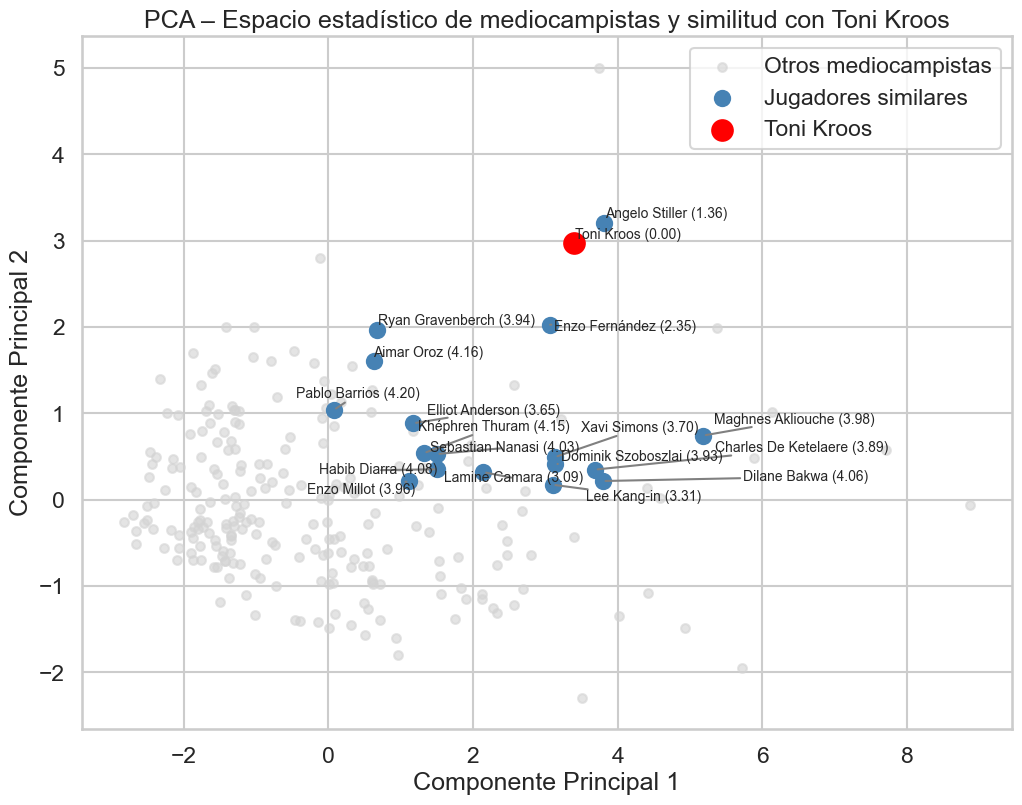

In [13]:
# =====================================================
# PCA – VISUALIZACIÓN MEJORADA (ETIQUETAS AJUSTADAS)
# =====================================================


# =====================================================
# 1. FILTRAR MEDIOCAMPISTAS
# =====================================================

df_mf = df[df["Pos"].str.contains("MF", na=False)]


# =====================================================
# 2. VARIABLES DEL MODELO
# =====================================================

features = [
    "Ast",
    "xAG",
    "PrgP",
    "PrgC",
    "Ast_90",
    "xAG_90"
]


# =====================================================
# 3. FILTROS DE SCOUTING
# =====================================================

median_age = df_mf["Age"].median()
median_min = df_mf["Min"].median()
median_90s = df_mf["90s"].median()

df_filtered = df_mf[
    (df_mf["Squad"] != "Real Madrid") &
    (df_mf["Age"] < median_age) &
    (df_mf["Min"] > median_min) &
    (df_mf["90s"] > median_90s)
]


# =====================================================
# 4. AÑADIR TONI KROOS
# =====================================================

kroos = df[df["Player"] == "Toni Kroos"]
df_filtered = pd.concat([df_filtered, kroos], ignore_index=True)


# =====================================================
# 5. ESTANDARIZAR VARIABLES
# =====================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filtered[features])


# =====================================================
# 6. CALCULAR DISTANCIA A KROOS
# =====================================================

kroos_index = df_filtered[df_filtered["Player"] == "Toni Kroos"].index[0]

kroos_vector = X_scaled[kroos_index].reshape(1, -1)

distances = euclidean_distances(kroos_vector, X_scaled)[0]

df_filtered["distance_to_kroos"] = distances


# =====================================================
# 7. PCA SOBRE DATASET FILTRADO
# =====================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_filtered["PCA1"] = X_pca[:,0]
df_filtered["PCA2"] = X_pca[:,1]


# =====================================================
# 8. JUGADORES DESTACADOS
# =====================================================

players = [
"Toni Kroos","Angelo Stiller","Enzo Fernández","Lamine Camara",
"Pablo Barrios","Aimar Oroz","Khéphren Thuram","Habib Diarra",
"Dilane Bakwa","Sebastian Nanasi","Maghnes Akliouche","Lee Kang-in",
"Elliot Anderson","Xavi Simons","Charles De Ketelaere","Dominik Szoboszlai",
"Ryan Gravenberch","Enzo Millot"
]

df_candidates = df_filtered[df_filtered["Player"].isin(players)]
df_background = df_filtered[~df_filtered["Player"].isin(players)]


# =====================================================
# 9. VISUALIZACIÓN
# =====================================================

plt.figure(figsize=(12,9))

# fondo con todos los mediocampistas

plt.scatter(
    df_background["PCA1"],
    df_background["PCA2"],
    color="lightgray",
    s=40,
    alpha=0.6,
    label="Otros mediocampistas"
)

# jugadores candidatos

plt.scatter(
    df_candidates[df_candidates["Player"]!="Toni Kroos"]["PCA1"],
    df_candidates[df_candidates["Player"]!="Toni Kroos"]["PCA2"],
    color="steelblue",
    s=120,
    label="Jugadores similares"
)

# Kroos

kroos_point = df_candidates[df_candidates["Player"]=="Toni Kroos"]

plt.scatter(
    kroos_point["PCA1"],
    kroos_point["PCA2"],
    color="red",
    s=220,
    label="Toni Kroos"
)


# =====================================================
# ETIQUETAS INTELIGENTES
# =====================================================

texts = []

for i,row in df_candidates.iterrows():

    label = f"{row['Player']} ({row['distance_to_kroos']:.2f})"

    texts.append(
        plt.text(
            row["PCA1"],
            row["PCA2"],
            label,
            fontsize=10
        )
    )

# ajusta automáticamente las etiquetas

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray'))


plt.title("PCA – Espacio estadístico de mediocampistas y similitud con Toni Kroos")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.legend()

plt.grid(True)

plt.show()

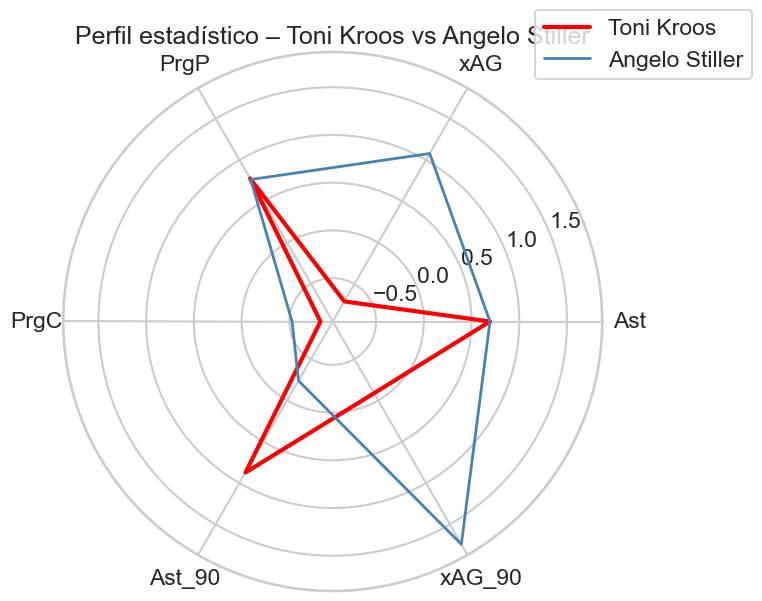

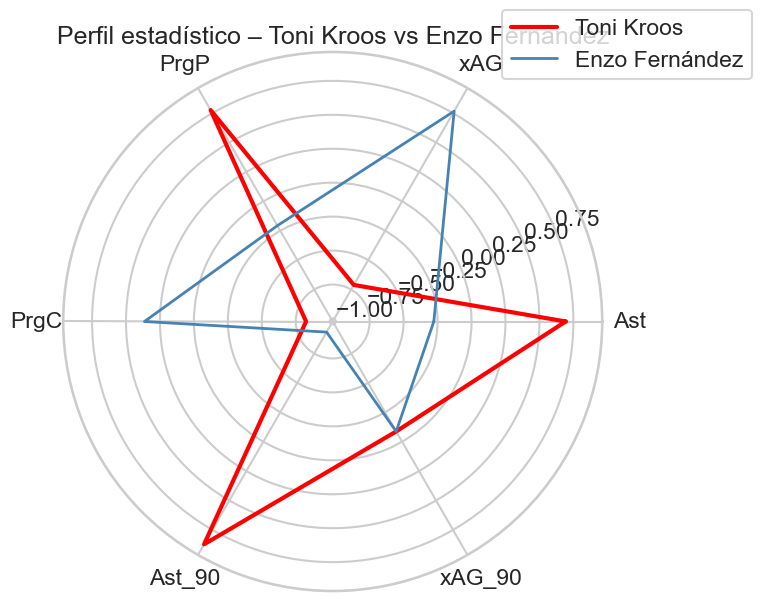

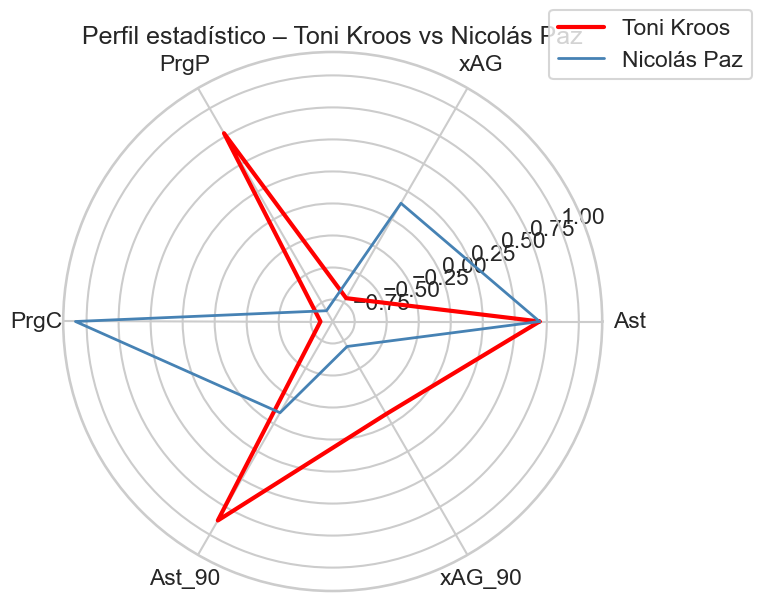

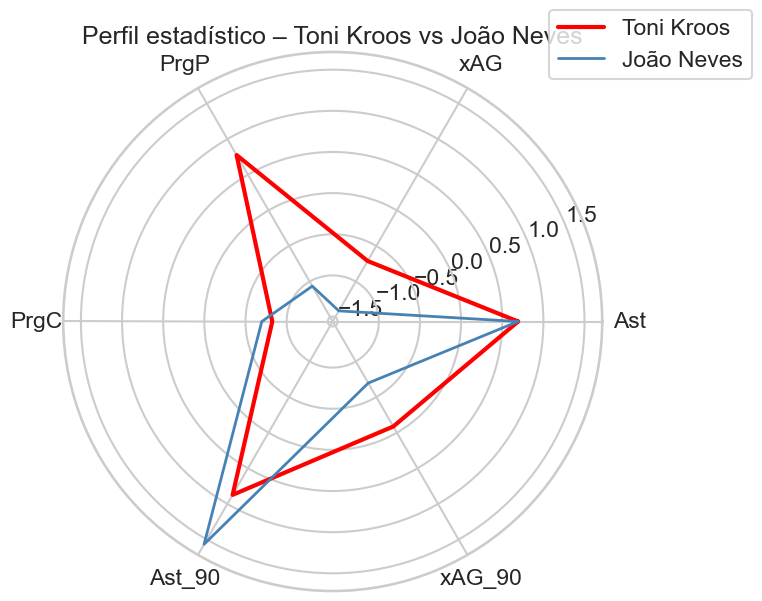

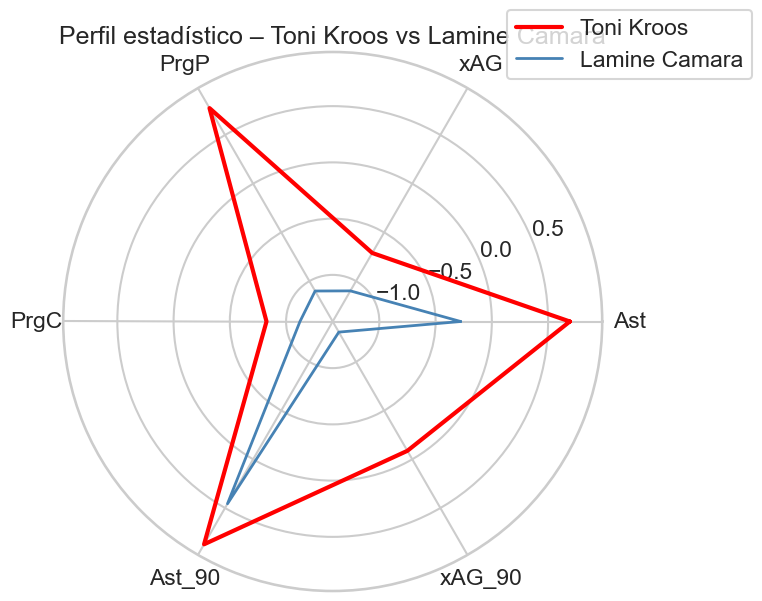

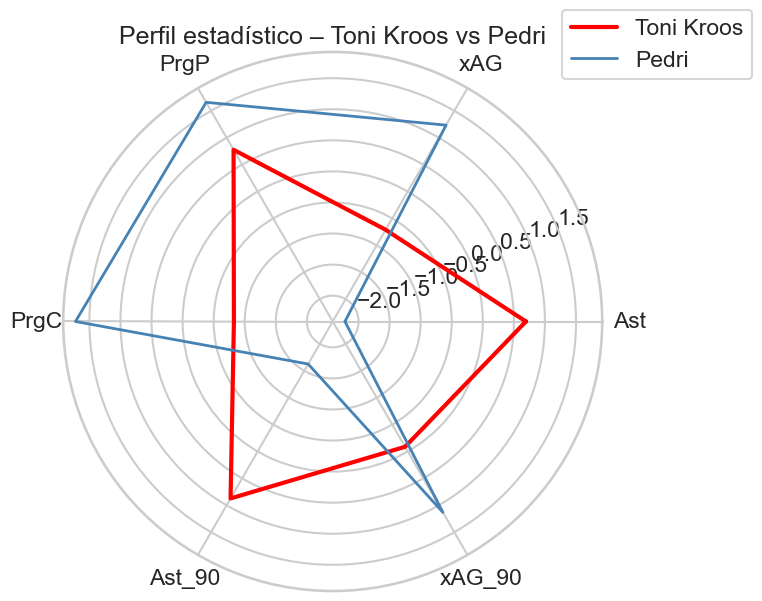

In [14]:
# =====================================================
# RADAR CHART – COMPARACIÓN INDIVIDUAL CON TONI KROOS
# =====================================================

# Este script genera un radar chart para cada jugador
# identificado como candidato en el modelo de similitud.
#
# Cada gráfico compara directamente el perfil estadístico
# del jugador con el de Toni Kroos.


# =====================================================
#  VARIABLES DEL MODELO
# =====================================================

features = [
    "Ast",
    "xAG",
    "PrgP",
    "PrgC",
    "Ast_90",
    "xAG_90"
]


# =====================================================
# JUGADORES A COMPARAR
# =====================================================

players = [
"Toni Kroos",
"Angelo Stiller",
"Enzo Fernández",
"Nicolás Paz",
"João Neves",
"Lamine Camara",
"Pedri"
]

df_radar = df[df["Player"].isin(players)]


# =====================================================
# ESTANDARIZAR VARIABLES
# =====================================================

# Se estandarizan las variables para permitir comparar
# correctamente métricas con escalas distintas.

scaler = StandardScaler()

data_scaled = scaler.fit_transform(df_radar[features])

df_scaled = pd.DataFrame(data_scaled, columns=features)

df_scaled["Player"] = df_radar["Player"].values


# =====================================================
# PREPARAR ESTRUCTURA DEL RADAR
# =====================================================

categories = features
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]


# =====================================================
# SEPARAR TONI KROOS
# =====================================================

kroos_data = df_scaled[df_scaled["Player"]=="Toni Kroos"]


# =====================================================
# GENERAR RADAR PARA CADA JUGADOR
# =====================================================

for player in players:

    if player == "Toni Kroos":
        continue

    player_data = df_scaled[df_scaled["Player"]==player]

    kroos_values = kroos_data[features].values.flatten().tolist()
    kroos_values += kroos_values[:1]

    player_values = player_data[features].values.flatten().tolist()
    player_values += player_values[:1]

    plt.figure(figsize=(7,7))

    # Kroos (referencia)

    plt.polar(
        angles,
        kroos_values,
        linewidth=3,
        label="Toni Kroos",
        color="red"
    )

    # Jugador candidato

    plt.polar(
        angles,
        player_values,
        linewidth=2,
        label=player,
        color="steelblue"
    )

    plt.xticks(angles[:-1], categories)

    plt.title(f"Perfil estadístico – Toni Kroos vs {player}")

    plt.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))

    plt.show()